# Final Project – Unit 3: FIFA Men's World Cup Matches (1970–2022)
### From Exploration to Insights

In this notebook I explore a dataset of FIFA Men's World Cup matches from 1970 to 2022, clean it, analyze it, and prepare it for a Streamlit dashboard.

**What this notebook covers:**
- Dataset overview and problem definition
- Loading and inspecting the data
- Cleaning (missing values, duplicates, data types)
- Descriptive statistics
- Exploratory Data Analysis (univariate, bivariate, multivariate)
- Insights summary
- Preparing the data for the dashboard / a simple ML step


## 1. Dataset Overview

**Dataset title:** FIFA Men's World Cup Dataset (1970–2022)

**Source:** Kaggle – https://www.kaggle.com/datasets/isfakiqbalchowdhuruy/fifa-mens-world-cup-dataset-1970-2022

**Description:** The dataset contains 1,322 match records (one row per team per match) covering every FIFA Men's World Cup from 1970 to 2022. It includes match results, team stats (possession, shots, passes, cards), and pre-match form features (prior win rate, head-to-head history).

**Why I selected it:** I'm interested in football, and this dataset has a good mix of numeric stats and categorical info (stage, host status, outcome), which lets me ask real questions about what actually predicts winning a World Cup match.


## 2. Problem Definition

**What is the dataset about?**
Each row represents one team's participation in one World Cup match, including their match stats and the result.

**Main questions I will explore:**
1. Does hosting the World Cup give a team an advantage?
2. Does a team's prior win rate (their form before the tournament/match) predict whether they win?
3. Are yellow/red cards more common in knockout stage matches than group stage matches?
4. Does possession actually lead to goals, or do shots on target matter more?

**What insights do I expect to uncover?**
I expect host nations to perform better due to crowd support, prior form to matter to some extent, and shots on target to matter more for scoring than possession alone.


## 3. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## 4. Data Loading & Structure

The raw file `fifa_wc_matches_raw.csv` is included in this repository, so we load it directly.


In [2]:
df = pd.read_csv("/content/fifa_wc_mens_match_dataset_1970_2022.csv")
df.head()


,tournament_name,stage_name,group_name,group_stage,knockout_stage,replayed,replay,match_date,match_time,stadium_name,...,passes_attempted_h2,corners_h1,corners_h2,fouls_h1,fouls_h2,yellow_cards_h1,yellow_cards_h2,red_cards_h1,red_cards_h2,outcome
0,1970 FIFA Men's World Cup,group stage,Group 1,1,0,0,0,1970-05-31,12:00,Estadio Azteca,...,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,Draw
1,1970 FIFA Men's World Cup,group stage,Group 1,1,0,0,0,1970-05-31,12:00,Estadio Azteca,...,NaN,NaN,NaN,NaN,NaN,3.0,1.0,0.0,0.0,Draw
2,1970 FIFA Men's World Cup,group stage,Group 2,1,0,0,0,1970-06-03,16:00,La Bombonera,...,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,Loss
3,1970 FIFA Men's World Cup,group stage,Group 3,1,0,0,0,1970-06-03,16:00,Estadio Jalisco,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,Win
4,1970 FIFA Men's World Cup,group stage,Group 3,1,0,0,0,1970-06-06,16:00,Estadio Jalisco,...,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,Win


In [3]:
print("Shape of the dataset:", df.shape)


Shape of the dataset: (1322, 70)


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Data columns (total 70 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tournament_name                1322 non-null   str    
 1   stage_name                     1322 non-null   str    
 2   group_name                     1322 non-null   str    
 3   group_stage                    1322 non-null   int64  
 4   knockout_stage                 1322 non-null   int64  
 5   replayed                       1322 non-null   int64  
 6   replay                         1322 non-null   int64  
 7   match_date                     1322 non-null   str    
 8   match_time                     1322 non-null   str    
 9   stadium_name                   1322 non-null   str    
 10  city_name                      1322 non-null   str    
 11  country_name                   1322 non-null   str    
 12  team_name                      1322 non-null   str    
 13 

In [5]:
df.describe()


,group_stage,knockout_stage,replayed,replay,home_team,away_team,goals_for,goals_against,extra_time,penalty_shootout,...,passes_attempted_h1,passes_attempted_h2,corners_h1,corners_h2,fouls_h1,fouls_h2,yellow_cards_h1,yellow_cards_h2,red_cards_h1,red_cards_h2
count,1322.000000,1322.000000,1322.0,1322.0,1322.000000,1322.000000,1322.000000,1322.000000,1322.000000,1322.000000,...,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,1322.000000,1322.000000,1322.000000,1322.000000
mean,0.748109,0.251891,0.0,0.0,0.496974,0.503026,1.263238,1.285930,0.082451,0.049924,...,222.925781,213.910156,2.269531,2.511719,7.561198,7.766927,0.801815,1.090772,0.045386,0.063540
std,0.434263,0.434263,0.0,0.0,0.500180,0.500180,1.250706,1.247531,0.275154,0.217871,...,67.961765,65.958116,1.670828,1.941751,3.157558,3.196984,0.858707,0.998526,0.208228,0.259071
min,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,75.000000,76.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,176.000000,166.000000,1.000000,1.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.0,0.0,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,213.500000,207.000000,2.000000,2.000000,7.000000,8.000000,1.000000,1.000000,0.000000,0.000000
75%,1.000000,1.000000,0.0,0.0,1.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,259.000000,251.000000,3.000000,4.000000,10.000000,10.000000,1.000000,2.000000,0.000000,0.000000
max,1.000000,1.000000,0.0,0.0,1.000000,1.000000,10.000000,9.000000,1.000000,1.000000,...,597.000000,559.000000,11.000000,10.000000,18.000000,18.000000,6.000000,7.000000,1.000000,2.000000


In [6]:
df.isnull().sum().sort_values(ascending=False).head(10)


passes_completed       554
shots                  554
corners                554
passes_attempted       554
shots_on_target        554
fouls                  554
shots_h2               554
passes_attempted_h1    554
shots_on_target_h2     554
shots_on_target_h1     554
dtype: int64

Note on missing values: Some columns have missing data — possession, shots, shots on target, passes completed, passes attempted, corners, and fouls. FIFA did not track these stats before 2002. So old matches do not have this data. This is not a random problem, it is missing for a clear reason. I will handle this in the cleaning step below.


## 5. Data Cleaning and Preprocessing

Steps applied:
1. Keep only the columns relevant to my questions (from the original 70).
2. Convert `match_date` to a proper datetime and extract the `year`.
3. Drop the duplicate `result` column (it's identical to `outcome`, just lowercase).
4. Check for duplicate rows.
5. Create a separate subset (`modern_df`) of matches from 2002 onward for questions that need possession/shots data, since that's where those stats are actually recorded.


In [7]:
relevant_cols = [
    'tournament_name', 'stage_name', 'group_stage', 'knockout_stage', 'match_date',
    'team_name', 'opponent_name', 'home_team', 'away_team',
    'goals_for', 'goals_against', 'is_host',
    'possession', 'shots', 'shots_on_target', 'passes_completed', 'passes_attempted',
    'corners', 'fouls', 'yellow_cards', 'red_cards',
    'team_prior_win_rate', 'team_prior_matches',
    'extra_time', 'penalty_shootout', 'outcome'
]

df_clean = df[relevant_cols].copy()
df_clean['match_date'] = pd.to_datetime(df_clean['match_date'])
df_clean['year'] = df_clean['match_date'].dt.year

print("Selected", len(relevant_cols), "columns out of", df.shape[1])
df_clean.head()


Selected 26 columns out of 70


,tournament_name,stage_name,group_stage,knockout_stage,match_date,team_name,opponent_name,home_team,away_team,goals_for,...,corners,fouls,yellow_cards,red_cards,team_prior_win_rate,team_prior_matches,extra_time,penalty_shootout,outcome,year
0,1970 FIFA Men's World Cup,group stage,1,0,1970-05-31,Mexico,Soviet Union,1,0,0,...,NaN,NaN,1,0,0.058824,17,0,0,Draw,1970
1,1970 FIFA Men's World Cup,group stage,1,0,1970-05-31,Soviet Union,Mexico,0,1,0,...,NaN,NaN,4,0,0.533333,15,0,0,Draw,1970
2,1970 FIFA Men's World Cup,group stage,1,0,1970-06-03,Sweden,Italy,0,1,0,...,NaN,NaN,1,0,0.500000,16,0,0,Loss,1970
3,1970 FIFA Men's World Cup,group stage,1,0,1970-06-03,Brazil,Czechoslovakia,1,0,4,...,NaN,NaN,1,0,0.625000,32,0,0,Win,1970
4,1970 FIFA Men's World Cup,group stage,1,0,1970-06-06,Romania,Czechoslovakia,1,0,2,...,NaN,NaN,1,0,0.200000,5,0,0,Win,1970


In [8]:
print("Duplicate rows:", df_clean.duplicated().sum())


Duplicate rows: 0


In [9]:

modern_df = df_clean[df_clean['possession'].notnull()].copy()
print("Full dataset:", df_clean.shape)
print("Modern-stats subset (2002-2022):", modern_df.shape)


Full dataset: (1322, 27)
Modern-stats subset (2002-2022): (768, 27)


In [10]:
df_clean.isnull().sum()

tournament_name          0
stage_name               0
group_stage              0
knockout_stage           0
match_date               0
team_name                0
opponent_name            0
home_team                0
away_team                0
goals_for                0
goals_against            0
is_host                  0
possession             554
shots                  554
shots_on_target        554
passes_completed       554
passes_attempted       554
corners                554
fouls                  554
yellow_cards             0
red_cards                0
team_prior_win_rate      0
team_prior_matches       0
extra_time               0
penalty_shootout         0
outcome                  0
year                     0
dtype: int64

## 6. Descriptive Statistics

In [11]:
df_clean[['goals_for', 'goals_against', 'yellow_cards', 'red_cards', 'team_prior_win_rate']].describe()


,goals_for,goals_against,yellow_cards,red_cards,team_prior_win_rate
count,1322.000000,1322.000000,1322.000000,1322.000000,1322.000000
mean,1.263238,1.285930,1.923601,0.116490,0.352201
std,1.250706,1.247531,1.265415,0.345908,0.212385
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.200000
50%,1.000000,1.000000,2.000000,0.000000,0.392857
75%,2.000000,2.000000,3.000000,0.000000,0.523810
max,10.000000,9.000000,8.000000,2.000000,0.833333


Interpretation: On average, a team scores about 1.3 goals per match and gets close to 2 yellow cards. The average prior win rate is 0.35. This means teams usually won about a third of their past matches before the World Cup.


## 7. Exploratory Data Analysis (EDA)

### Univariate Analysis


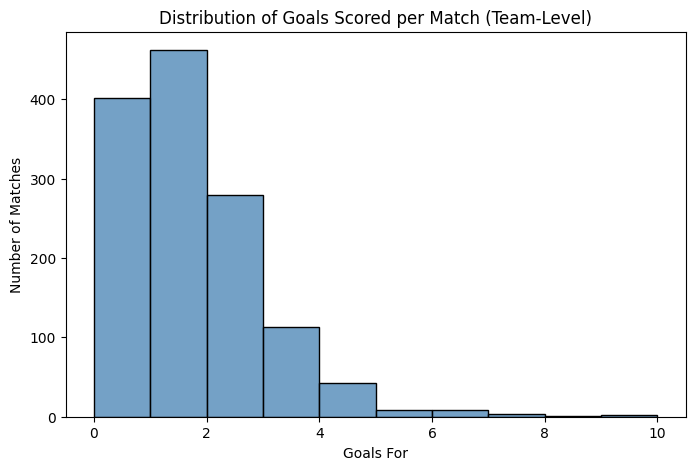

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['goals_for'], bins=10, kde=False, color='steelblue')
plt.title("Distribution of Goals Scored per Match (Team-Level)")
plt.xlabel("Goals For")
plt.ylabel("Number of Matches")
plt.show()


Quick insight: Most teams score 0-2 goals per match. Scoring 4 or more goals is rare.


/tmp/ipykernel_549/3534956419.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='outcome', order=['Win','Draw','Loss'],palette=['green','orange','red'])


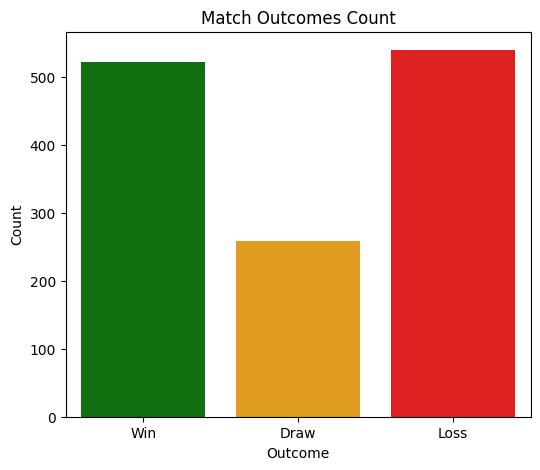

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(data=df_clean, x='outcome', order=['Win','Draw','Loss'],palette=['green','orange','red'])
plt.title("Match Outcomes Count")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()


/tmp/ipykernel_549/1936488226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=modern_df, x='outcome', y='shots_on_target', order=['Win','Draw','Loss'] ,palette=['green','orange','red'])


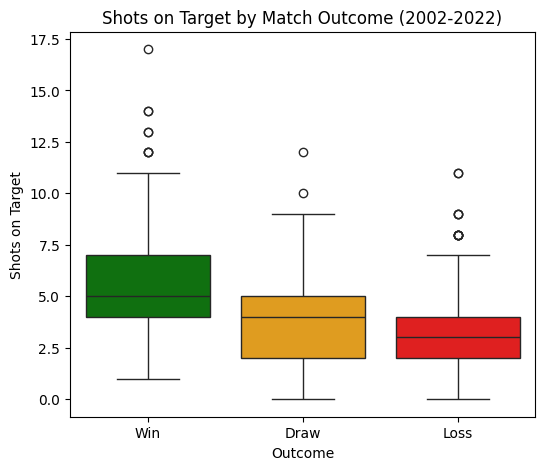

In [14]:
plt.figure(figsize=(6,5))
sns.boxplot(data=modern_df, x='outcome', y='shots_on_target', order=['Win','Draw','Loss'] ,palette=['green','orange','red'])
plt.title("Shots on Target by Match Outcome (2002-2022)")
plt.xlabel("Outcome")
plt.ylabel("Shots on Target")
plt.show()


Quick insight: Winning teams usually have more shots on target than teams that draw or lose.


### Bivariate & Multivariate Analysis

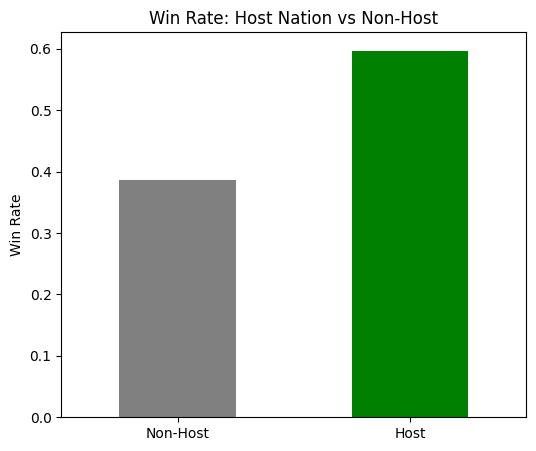

Non-Host    0.385714
Host        0.596774
Name: outcome, dtype: float64


In [15]:
host_outcome = df_clean.groupby('is_host')['outcome'].apply(lambda x: (x=='Win').mean())
host_outcome.index = ['Non-Host', 'Host']

plt.figure(figsize=(6,5))
host_outcome.plot(kind='bar', color=['gray', 'green'])
plt.title("Win Rate: Host Nation vs Non-Host")
plt.ylabel("Win Rate")
plt.xticks(rotation=0)
plt.show()

print(host_outcome)


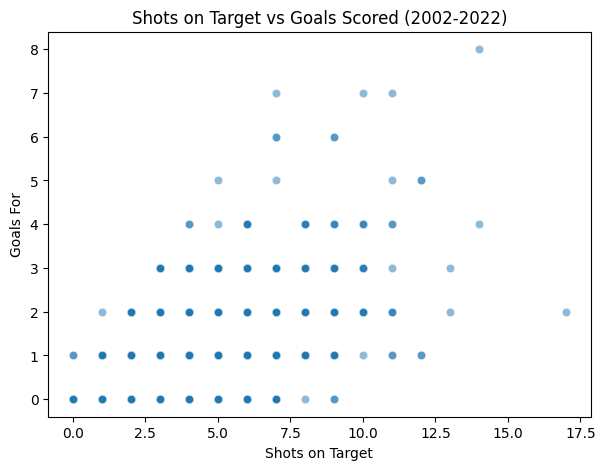

Correlation (shots_on_target vs goals_for): 0.54
Correlation (possession vs goals_for): 0.11


In [16]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=modern_df, x='shots_on_target', y='goals_for', alpha=0.5)
plt.title("Shots on Target vs Goals Scored (2002-2022)")
plt.xlabel("Shots on Target")
plt.ylabel("Goals For")
plt.show()

print("Correlation (shots_on_target vs goals_for):", round(modern_df['shots_on_target'].corr(modern_df['goals_for']), 2))
print("Correlation (possession vs goals_for):", round(modern_df['possession'].corr(modern_df['goals_for']), 2))


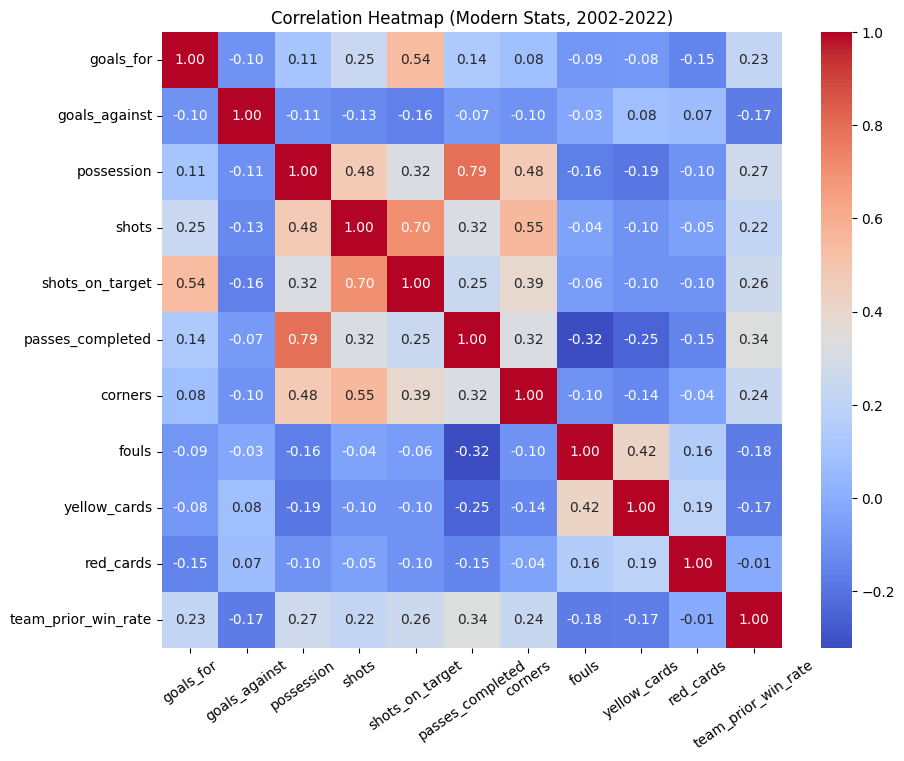

In [17]:
numeric_cols = ['goals_for', 'goals_against', 'possession', 'shots', 'shots_on_target',
                 'passes_completed', 'corners', 'fouls', 'yellow_cards', 'red_cards', 'team_prior_win_rate']

plt.figure(figsize=(10,8))
sns.heatmap(modern_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap (Modern Stats, 2002-2022)")
plt.xticks(rotation=35)
plt.show()


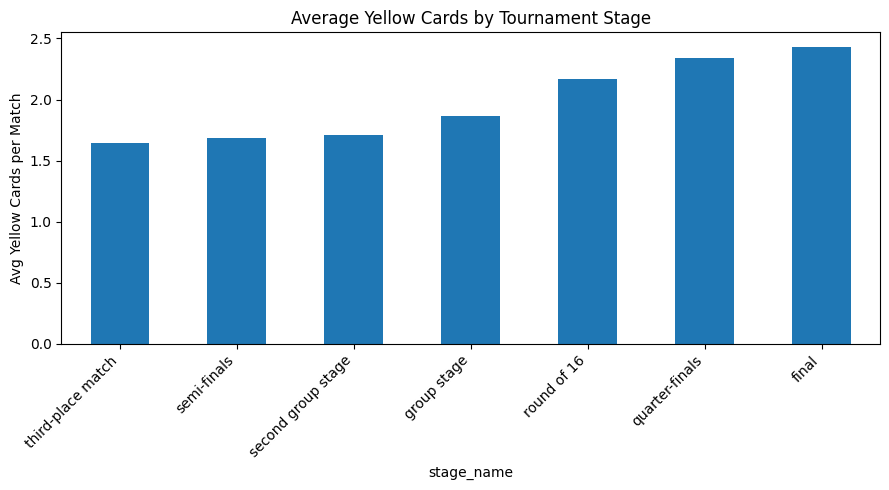

                    yellow_cards  red_cards
stage_name                                 
third-place match       1.640000   0.000000
semi-finals             1.680851   0.063830
second group stage      1.707317   0.097561
group stage             1.862869   0.110759
round of 16             2.165563   0.145695
quarter-finals          2.341463   0.182927
final                   2.428571   0.178571


In [18]:
cards_by_stage = df_clean.groupby('stage_name')[['yellow_cards','red_cards']].mean().sort_values('yellow_cards')

plt.figure(figsize=(9,5))
cards_by_stage['yellow_cards'].plot(kind='bar')
plt.title("Average Yellow Cards by Tournament Stage")
plt.ylabel("Avg Yellow Cards per Match")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(cards_by_stage)


## 8. Insights Summary

- Hosting helps: host teams won about 60% of their matches. Non-host teams won about 39%. Host teams also scored a bit more goals on average.
- Form matters a little: teams that won had a higher average prior win rate (0.41) than teams that lost (0.30).
- Knockout matches are more physical: average yellow cards go up from 1.86 in the group stage to 2.12 in knockout matches.
- Shots on target matter more than possession: shots on target link to goals much more strongly (r = 0.54) than possession does (r = 0.11).
- Outliers: a few matches have 4 or more goals for one team. These are real results, not mistakes, so I kept them.


## 9. Final Summary

Main insights: hosting the World Cup and shots on target are the strongest signs of winning. Possession alone does not predict winning well. Knockout matches have a few more cards than group stage matches.

What I learned: I learned to check why data is missing before deciding how to fix it. The missing stats before 2002 were not random, so I made a separate group for modern matches instead of dropping or filling them blindly.

Limitations: the dataset only covers 1970 to 2022. Prior win rate is based on a small number of past matches, so it is not a perfect measure of team strength.

Recommendations: it would be useful to add FIFA world rankings for each match in future analysis.


## 10. Saving Clean Dataset


In [19]:
df_clean.to_csv("fifa_wc_matches_clean.csv", index=False)

print("Saved: fifa_wc_matches_clean.csv")


Saved: fifa_wc_matches_clean.csv
